In [478]:
# Importación de librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import holidays
from sklearn import datasets, model_selection, metrics, preprocessing, linear_model, ensemble, tree, neighbors, svm, cluster, decomposition

In [479]:
# Cargar los datos de ventas y competencias desde la carpeta raw
ventas_path = '../data/raw/entrenamiento/ventas.csv'
competencia_path = '../data/raw/entrenamiento/competencia.csv'

df_ventas = pd.read_csv(ventas_path)
df_competencia = pd.read_csv(competencia_path)

# Mostrar las primeras filas de los dataframes para verificación
display(df_ventas.head())
display(df_competencia.head())

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_002,112.56,108.61,115.58
2,2021-10-25,PROD_003,79.79,78.44,80.11
3,2021-10-25,PROD_004,72.60,67.29,74.45
4,2021-10-25,PROD_005,37.71,33.60,33.07


In [480]:
df_ventas.columns

Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos'],
      dtype='object')

In [481]:
df_competencia.columns

Index(['fecha', 'producto_id', 'Amazon', 'Decathlon', 'Deporvillage'], dtype='object')

In [482]:
# Análisis de calidad de datos para df_ventas
print('--- Tipos de variables ---')
display(df_ventas.dtypes)

print('\n--- Valores nulos por columna ---')
display(df_ventas.isnull().sum())

print('\n--- Porcentaje de nulos por columna ---')
display((df_ventas.isnull().mean() * 100).round(2))

print('\n--- Duplicados ---')
duplicados = df_ventas.duplicated().sum()
print(f'Registros duplicados: {duplicados}')

print('\n--- Estadísticos descriptivos (numéricas) ---')
display(df_ventas.describe())

print('\n--- Estadísticos descriptivos (categóricas) ---')
categoricas = df_ventas.select_dtypes(include=['object', 'category'])
if not categoricas.empty:
    display(categoricas.describe())
else:
    print('No hay variables categóricas.')

print('\n--- Informe de calidad de datos generado ---')

--- Tipos de variables ---


fecha                 object
producto_id           object
nombre                object
categoria             object
subcategoria          object
precio_base            int64
es_estrella             bool
unidades_vendidas      int64
precio_venta         float64
ingresos             float64
dtype: object


--- Valores nulos por columna ---


fecha                0
producto_id          0
nombre               0
categoria            0
subcategoria         0
precio_base          0
es_estrella          0
unidades_vendidas    0
precio_venta         0
ingresos             0
dtype: int64


--- Porcentaje de nulos por columna ---


...


--- Duplicados ---
Registros duplicados: 0

--- Estadísticos descriptivos (numéricas) ---


,precio_base,unidades_vendidas,precio_venta,ingresos
count,3552.000000,3552.00000,3552.000000,3552.000000
mean,123.125000,4.87866,121.816546,605.972323
std,165.576753,6.31102,164.017963,1079.071192
min,20.000000,1.00000,19.000000,19.460000
25%,48.750000,2.00000,47.212500,131.535000
50%,72.500000,3.00000,71.810000,216.570000
75%,118.750000,5.00000,118.220000,639.637500
max,830.000000,85.00000,854.220000,14508.400000



--- Estadísticos descriptivos (categóricas) ---


,fecha,producto_id,nombre,categoria,subcategoria
count,3552,3552,3552,3552,3552
unique,148,24,24,4,16
top,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running
freq,24,148,148,1184,888



--- Informe de calidad de datos generado ---


In [483]:

# Informe de calidad de datos para df_competencia
print('--- Tipos de variables (df_competencia) ---')
display(df_competencia.dtypes)

print('\n--- Valores nulos por columna (df_competencia) ---')
display(df_competencia.isnull().sum())

print('\n--- Porcentaje de nulos por columna (df_competencia) ---')
display((df_competencia.isnull().mean() * 100).round(2))

print('\n--- Duplicados (df_competencia) ---')
duplicados_comp = df_competencia.duplicated().sum()
print(f'Registros duplicados: {duplicados_comp}')

print('\n--- Estadísticos descriptivos (numéricas, df_competencia) ---')
display(df_competencia.describe())

print('\n--- Estadísticos descriptivos (categóricas, df_competencia) ---')
categoricas_comp = df_competencia.select_dtypes(include=['object', 'category'])
if not categoricas_comp.empty:
    display(categoricas_comp.describe())
else:
    print('No hay variables categóricas.')

print('\n--- Informe de calidad de datos generado para df_competencia ---')

--- Tipos de variables (df_competencia) ---


fecha            object
producto_id      object
Amazon          float64
Decathlon       float64
Deporvillage    float64
dtype: object


--- Valores nulos por columna (df_competencia) ---


fecha           0
producto_id     0
Amazon          0
Decathlon       0
Deporvillage    0
dtype: int64


--- Porcentaje de nulos por columna (df_competencia) ---


...


--- Duplicados (df_competencia) ---
Registros duplicados: 0

--- Estadísticos descriptivos (numéricas, df_competencia) ---


,Amazon,Decathlon,Deporvillage
count,3552.000000,3552.000000,3552.000000
mean,118.623407,111.412182,118.894628
std,156.095628,148.508132,160.216448
min,16.850000,15.450000,16.770000
25%,47.117500,43.285000,47.310000
50%,73.180000,66.285000,72.700000
75%,114.342500,111.172500,114.985000
max,858.350000,867.337500,932.325000



--- Estadísticos descriptivos (categóricas, df_competencia) ---


,fecha,producto_id
count,3552,3552
unique,148,24
top,2021-10-25,PROD_001
freq,24,148



--- Informe de calidad de datos generado para df_competencia ---


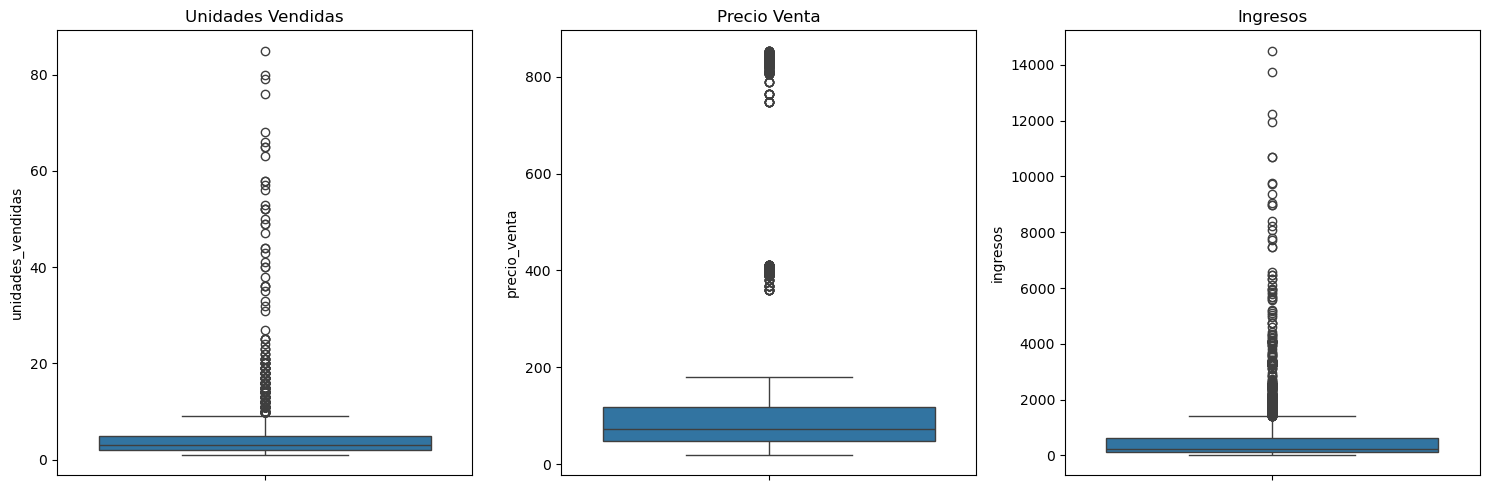

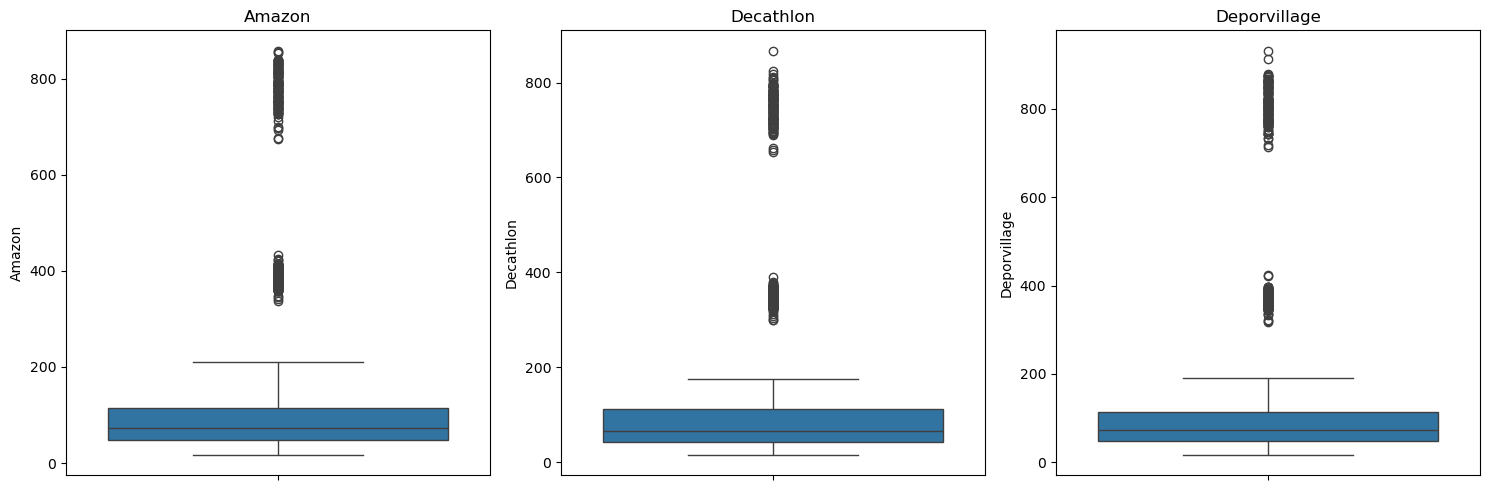

In [484]:
# Conversión de columna fecha a tipo datetime en df_ventas
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])
df_competencia['fecha'] = pd.to_datetime(df_competencia['fecha'])

# Visualización de posibles outliers en variables numéricas de df_ventas
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=df_ventas['unidades_vendidas'])
plt.title('Unidades Vendidas')
plt.subplot(1, 3, 2)
sns.boxplot(y=df_ventas['precio_venta'])
plt.title('Precio Venta')
plt.subplot(1, 3, 3)
sns.boxplot(y=df_ventas['ingresos'])
plt.title('Ingresos')   
plt.tight_layout()
plt.show()

# Visualización de posibles outliers en variables numéricas de df_competencia
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=df_competencia['Amazon'])
plt.title('Amazon')
plt.subplot(1, 3, 2)
sns.boxplot(y=df_competencia['Decathlon'])
plt.title('Decathlon')
plt.subplot(1, 3, 3)
sns.boxplot(y=df_competencia['Deporvillage'])
plt.title('Deporvillage')
plt.tight_layout()
plt.show()

In [485]:
# Identificación y análisis de outliers extremos en df_ventas
# Mostramos los valores por encima del percentil 99 para cada variable numérica relevante
for col in ['unidades_vendidas', 'precio_venta', 'ingresos']:
    p99 = df_ventas[col].quantile(0.99)
    outliers = df_ventas[df_ventas[col] > p99]
    print(f'--- Outliers en {col} (por encima del percentil 99, valor > {p99:.2f}) ---')
    display(outliers[["fecha", "producto_id", col]])
    print(f'Total de outliers en {col}: {outliers.shape[0]}')
    print('\n')

# Repite el análisis para df_competencia
for col in ['Amazon', 'Decathlon', 'Deporvillage']:
    p99 = df_competencia[col].quantile(0.99)
    outliers = df_competencia[df_competencia[col] > p99]
    print(f'--- Outliers en {col} (por encima del percentil 99, valor > {p99:.2f}) ---')
    display(outliers[["fecha", "producto_id", col]])
    print(f'Total de outliers en {col}: {outliers.shape[0]}')
    print('\n')

--- Outliers en unidades_vendidas (por encima del percentil 99, valor > 25.98) ---


,fecha,producto_id,unidades_vendidas
768,2021-11-26,PROD_001,44
769,2021-11-26,PROD_002,40
792,2021-11-27,PROD_001,49
793,2021-11-27,PROD_002,47
816,2021-11-28,PROD_001,36
817,2021-11-28,PROD_002,50
840,2021-11-29,PROD_001,36
841,2021-11-29,PROD_002,31
864,2021-11-30,PROD_001,35
1632,2022-11-25,PROD_001,58


Total de outliers en unidades_vendidas: 36


--- Outliers en precio_venta (por encima del percentil 99, valor > 839.98) ---


,fecha,producto_id,precio_venta
135,2021-10-30,PROD_016,840.40
207,2021-11-02,PROD_016,843.68
231,2021-11-03,PROD_016,846.97
327,2021-11-07,PROD_016,853.13
375,2021-11-09,PROD_016,848.16
423,2021-11-11,PROD_016,840.07
447,2021-11-12,PROD_016,841.41
495,2021-11-14,PROD_016,848.42
543,2021-11-16,PROD_016,849.36
639,2021-11-20,PROD_016,853.77


Total de outliers en precio_venta: 36


--- Outliers en ingresos (por encima del percentil 99, valor > 5143.85) ---


...

Total de outliers en Amazon: 36


--- Outliers en Decathlon (por encima del percentil 99, valor > 774.52) ---


,fecha,producto_id,Decathlon
1743,2022-11-29,PROD_016,818.0500
1767,2022-11-30,PROD_016,797.1875
2055,2023-11-05,PROD_016,784.5400
2223,2023-11-12,PROD_016,777.6300
2607,2023-11-28,PROD_016,824.2750
2631,2023-11-29,PROD_016,867.3375
2679,2024-10-25,PROD_016,783.0000
2703,2024-10-26,PROD_016,783.6300
2727,2024-10-27,PROD_016,811.8100
2751,2024-10-28,PROD_016,791.7600


Total de outliers en Decathlon: 36


--- Outliers en Deporvillage (por encima del percentil 99, valor > 847.62) ---


,fecha,producto_id,Deporvillage
879,2021-11-30,PROD_016,868.3125
1671,2022-11-26,PROD_016,856.8625
1743,2022-11-29,PROD_016,876.0250
1767,2022-11-30,PROD_016,864.5625
2103,2023-11-07,PROD_016,853.1100
2391,2023-11-19,PROD_016,850.3800
2535,2023-11-25,PROD_016,861.0000
2559,2023-11-26,PROD_016,867.9875
2607,2023-11-28,PROD_016,913.5750
2631,2023-11-29,PROD_016,932.3250


Total de outliers en Deporvillage: 36




In [486]:
df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[ns]
 1   producto_id        3552 non-null   object        
 2   nombre             3552 non-null   object        
 3   categoria          3552 non-null   object        
 4   subcategoria       3552 non-null   object        
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 253.3+ KB


In [487]:
df_competencia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         3552 non-null   datetime64[ns]
 1   producto_id   3552 non-null   object        
 2   Amazon        3552 non-null   float64       
 3   Decathlon     3552 non-null   float64       
 4   Deporvillage  3552 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 138.9+ KB


In [488]:
# Integración de df_ventas y df_competencia en un solo DataFrame
df = pd.merge(df_ventas, df_competencia, on=["fecha", "producto_id"], how="inner")

# Mostrar las primeras filas del DataFrame integrado para verificación
display(df.head())

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


## Análisis exploratorio completo de `df`
En las siguientes celdas se realiza un análisis exploratorio de los datos integrados en el DataFrame `df`, incluyendo visualizaciones y descripciones relevantes para entender el comportamiento de las ventas y la competencia.

In [489]:
# Resumen general y preparación de columnas auxiliares para análisis temporal y categórico
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia_semana'] = df['fecha'].dt.day_name(locale='es_ES')

# Identificación de fechas de Black Friday (último viernes de noviembre de cada año)
def obtener_blackfridays(df):
    blackfridays = []
    for año in df['año'].unique():
        nov = df[(df['año'] == año) & (df['mes'] == 11)]
        # Último viernes de noviembre
        viernes = nov[nov['fecha'].dt.weekday == 4]
        if not viernes.empty:
            blackfridays.append(viernes['fecha'].max())
    return blackfridays

blackfridays = obtener_blackfridays(df)
print('Fechas de Black Friday:', blackfridays)

Fechas de Black Friday: [Timestamp('2021-11-26 00:00:00'), Timestamp('2022-11-25 00:00:00'), Timestamp('2023-11-24 00:00:00'), Timestamp('2024-11-29 00:00:00')]


### 1. Evolución temporal anual de unidades vendidas
Se muestra un gráfico de líneas para cada año, representando la suma de unidades vendidas por fecha. Se marcan los días de Black Friday en cada año.

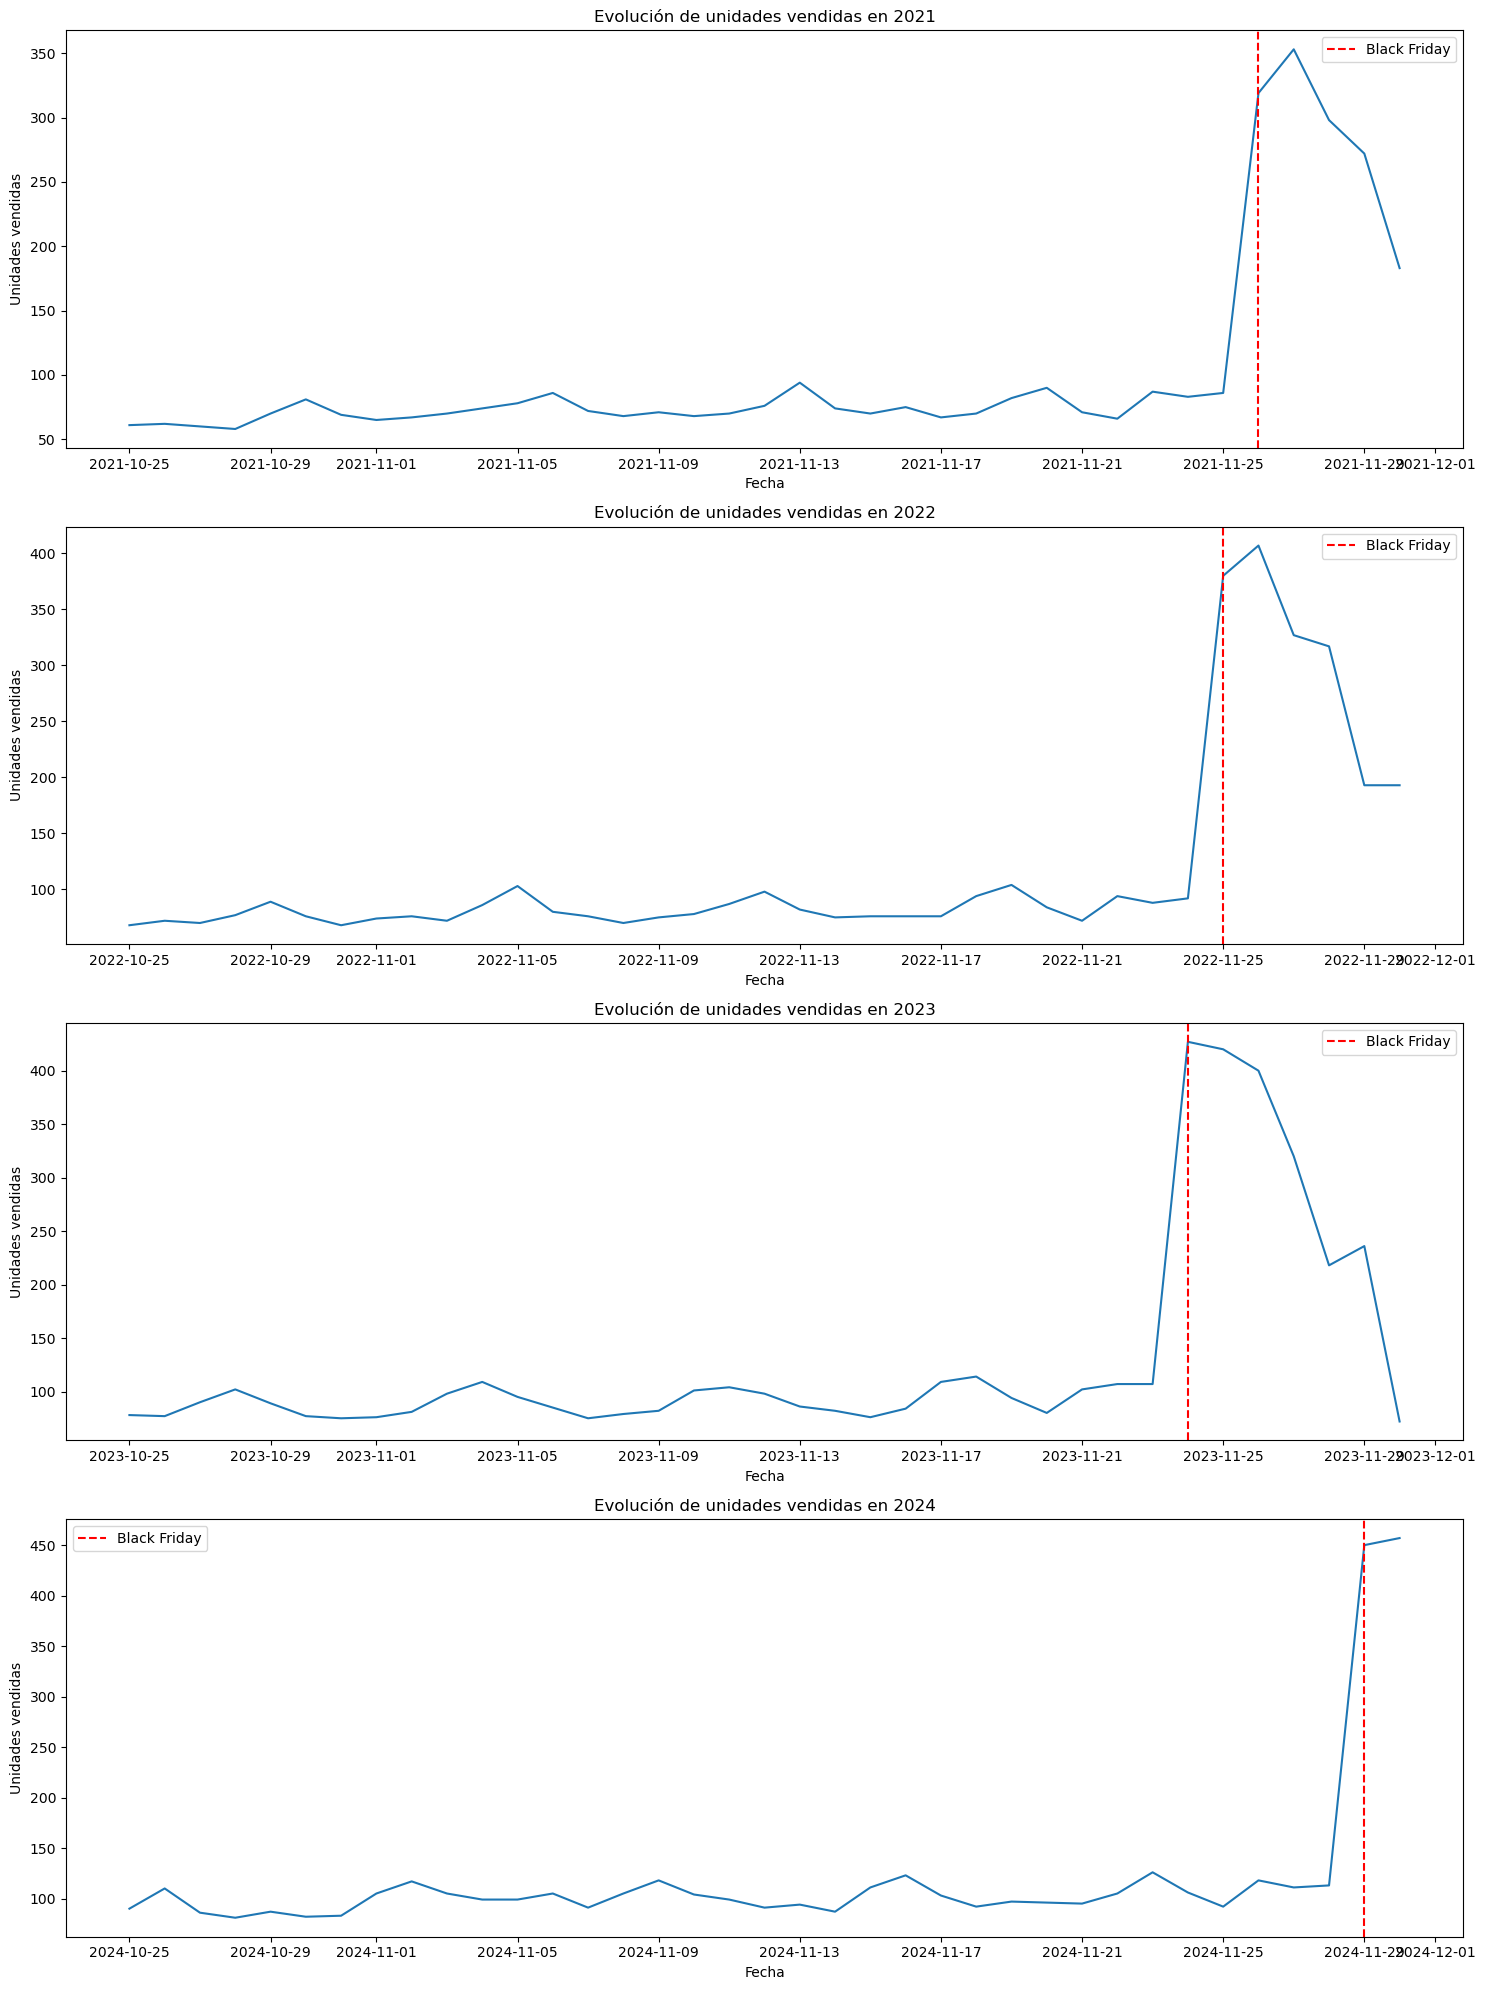

In [490]:
# Gráfico de líneas por año con suma de unidades vendidas y Black Fridays
anios = sorted(df['año'].unique())
fig, axes = plt.subplots(len(anios), 1, figsize=(15, 5 * len(anios)), sharex=False)
if len(anios) == 1:
    axes = [axes]
for i, año in enumerate(anios):
    df_anio = df[df['año'] == año].groupby('fecha')['unidades_vendidas'].sum().reset_index()
    sns.lineplot(data=df_anio, x='fecha', y='unidades_vendidas', ax=axes[i])
    axes[i].set_title(f'Evolución de unidades vendidas en {año}')
    axes[i].set_ylabel('Unidades vendidas')
    axes[i].set_xlabel('Fecha')
    # Marcar Black Friday
    bf = [d for d in blackfridays if d.year == año]
    for bfd in bf:
        axes[i].axvline(bfd, color='red', linestyle='--', label='Black Friday')
    if bf:
        axes[i].legend()
plt.tight_layout()
plt.show()

### 2. Suma de unidades vendidas por día de la semana
A continuación, se muestra un gráfico de barras con la suma total de unidades vendidas para cada día de la semana.

C:\Users\didac\AppData\Local\Temp\ipykernel_39792\130256517.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  suma_dias = df.groupby('dia_semana_es')['unidades_vendidas'].sum().reindex(orden_dias_es)
C:\Users\didac\AppData\Local\Temp\ipykernel_39792\130256517.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=suma_dias.index, y=suma_dias.values, palette='viridis')


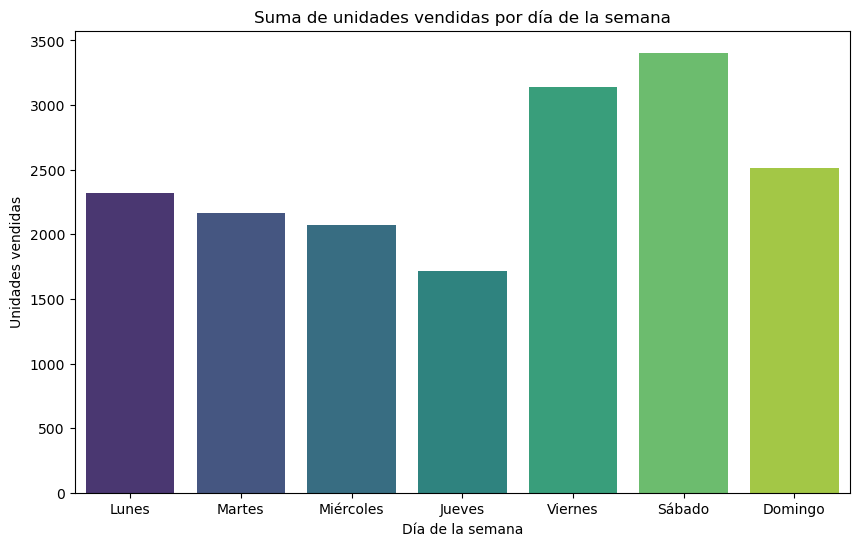

In [491]:
# Gráfico de barras: suma de unidades vendidas por día de la semana
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
orden_dias_es = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
df['dia_semana_es'] = df['fecha'].dt.day_name(locale='es_ES')
df['dia_semana_es'] = pd.Categorical(df['dia_semana_es'], categories=orden_dias_es, ordered=True)
suma_dias = df.groupby('dia_semana_es')['unidades_vendidas'].sum().reindex(orden_dias_es)
plt.figure(figsize=(10,6))
sns.barplot(x=suma_dias.index, y=suma_dias.values, palette='viridis')
plt.title('Suma de unidades vendidas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Unidades vendidas')
plt.show()

### 3. Suma de unidades vendidas por categoría
A continuación, se muestra un gráfico de barras con la suma total de unidades vendidas para cada categoría de producto.

C:\Users\didac\AppData\Local\Temp\ipykernel_39792\191216337.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=suma_categoria.index, y=suma_categoria.values, palette='crest')


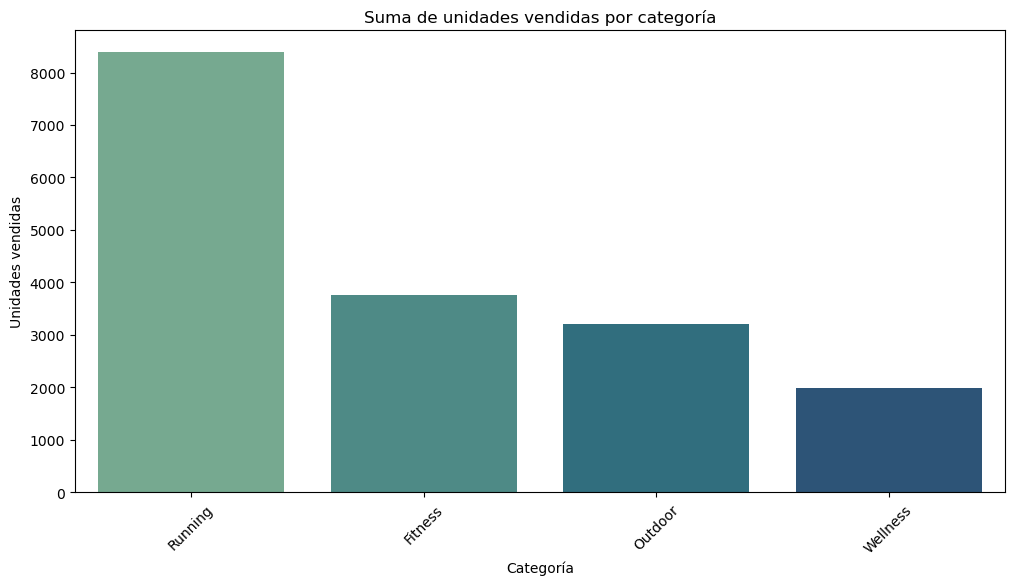

In [492]:
# Gráfico de barras: suma de unidades vendidas por categoría
suma_categoria = df.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=suma_categoria.index, y=suma_categoria.values, palette='crest')
plt.title('Suma de unidades vendidas por categoría')
plt.xlabel('Categoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.show()

### 4. Suma de unidades vendidas por subcategoría
A continuación, se muestra un gráfico de barras con la suma total de unidades vendidas para cada subcategoría de producto.

C:\Users\didac\AppData\Local\Temp\ipykernel_39792\3891278203.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=suma_subcat.index, y=suma_subcat.values, palette='mako')


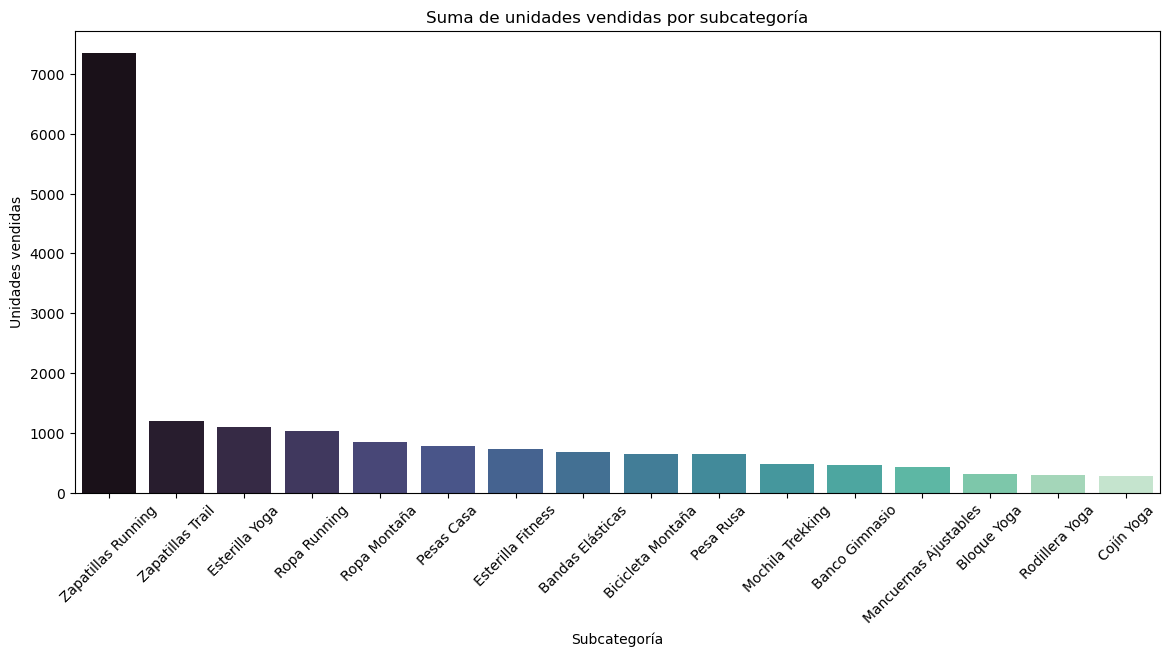

In [493]:
# Gráfico de barras: suma de unidades vendidas por subcategoría
suma_subcat = df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False)
plt.figure(figsize=(14,6))
sns.barplot(x=suma_subcat.index, y=suma_subcat.values, palette='mako')
plt.title('Suma de unidades vendidas por subcategoría')
plt.xlabel('Subcategoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.show()

### 5. Suma de unidades vendidas por top productos
A continuación, se muestra un gráfico de barras con la suma total de unidades vendidas para los 10 productos más vendidos.

C:\Users\didac\AppData\Local\Temp\ipykernel_39792\1090190921.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=suma_productos.values, y=suma_productos.index, palette='flare')


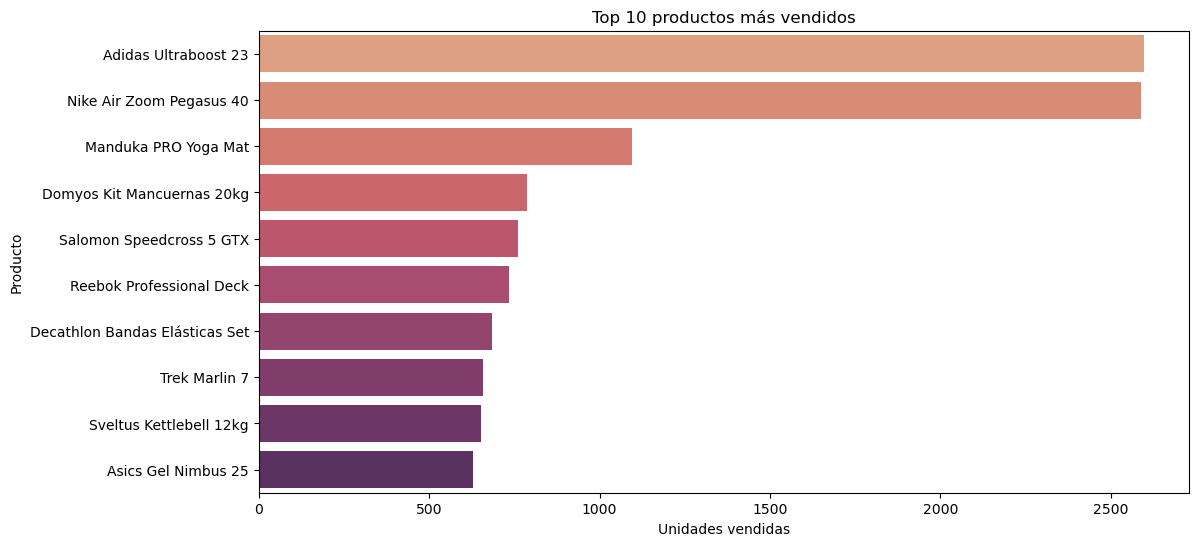

In [494]:
# Gráfico de barras: top 10 productos más vendidos
suma_productos = df.groupby('nombre')['unidades_vendidas'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=suma_productos.values, y=suma_productos.index, palette='flare')
plt.title('Top 10 productos más vendidos')
plt.xlabel('Unidades vendidas')
plt.ylabel('Producto')
plt.show()

### 6. Análisis de la densidad de distribución de precios
A continuación, se muestran gráficos de densidad (KDE) para comparar la distribución de los precios de venta propios (`precio_venta`) y los precios de Amazon (`Amazon`).

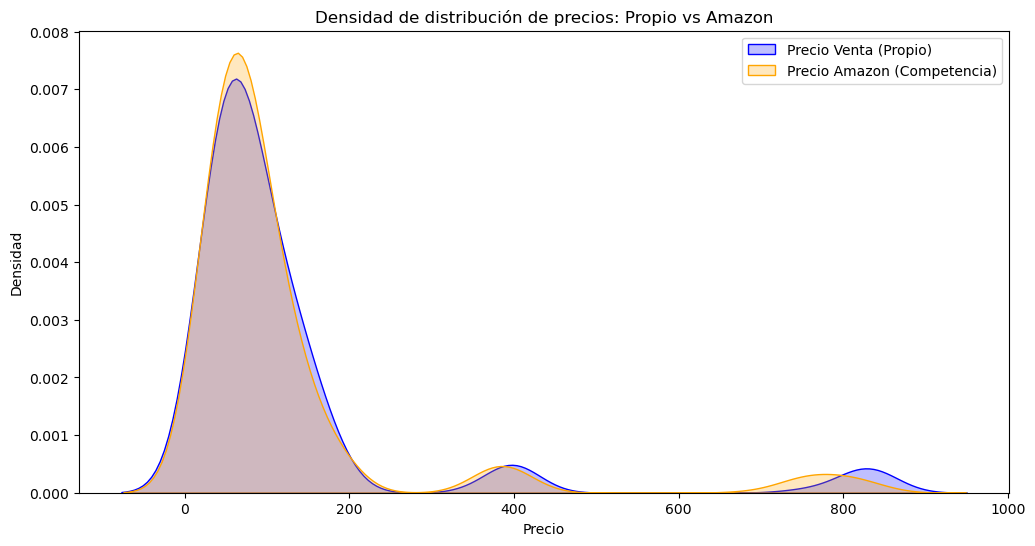

In [495]:
# Gráficos de densidad de precios propios y de Amazon
plt.figure(figsize=(12,6))
sns.kdeplot(df['precio_venta'], label='Precio Venta (Propio)', fill=True, color='blue')
sns.kdeplot(df['Amazon'], label='Precio Amazon (Competencia)', fill=True, color='orange')
plt.title('Densidad de distribución de precios: Propio vs Amazon')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.show()

In [496]:
# Creación de variables temporales y de calendario
import holidays

df['año'] = df['fecha'].dt.year
# Mes en número y nombre
meses_es = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
df['mes'] = df['fecha'].dt.month
# Nombre del mes en español
try:
    df['mes_nombre'] = df['fecha'].dt.month.apply(lambda x: meses_es[x-1])
except:
    df['mes_nombre'] = df['mes']
df['dia_mes'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.dayofweek  # 0=Lunes, 6=Domingo
df['nombre_dia_semana'] = df['fecha'].dt.day_name(locale='es_ES')
df['es_fin_semana'] = df['dia_semana'].isin([5,6])
spain_holidays = holidays.country_holidays('ES', years=df['año'].unique())
df['es_festivo'] = df['fecha'].isin(spain_holidays)

# Black Friday: último viernes de noviembre
def es_black_friday(fecha):
    if fecha.month == 11:
        # Último viernes de noviembre
        ultimo_viernes = max([d for d in pd.date_range(start=fecha.replace(day=1), end=fecha.replace(day=30)) if d.weekday() == 4])
        return fecha == ultimo_viernes
    return False
df['es_Black_Friday'] = df['fecha'].apply(es_black_friday)

# Cyber Monday: lunes siguiente al Black Friday
def es_cyber_monday(fecha):
    if fecha.month == 11:
        # Último viernes de noviembre
        ultimo_viernes = max([d for d in pd.date_range(start=fecha.replace(day=1), end=fecha.replace(day=30)) if d.weekday() == 4])
        cyber_monday = ultimo_viernes + pd.Timedelta(days=3)
        return fecha == cyber_monday
    return False
df['es_Cyber_Monday'] = df['fecha'].apply(es_cyber_monday)

# Semana del año
# Semana del año
df['semana_año'] = df['fecha'].dt.isocalendar().week
# Día del año
df['dia_año'] = df['fecha'].dt.dayofyear
# Trimestre
df['trimestre'] = df['fecha'].dt.quarter


# Mostrar las primeras filas para verificación
display(df.head())

C:\Users\didac\AppData\Local\Temp\ipykernel_39792\2524763783.py:18: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['es_festivo'] = df['fecha'].isin(spain_holidays)


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,mes_nombre,dia_mes,nombre_dia_semana,es_fin_semana,es_festivo,es_Black_Friday,es_Cyber_Monday,semana_año,dia_año,trimestre
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,Octubre,25,Lunes,False,False,False,False,43,298,4
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,Octubre,25,Lunes,False,False,False,False,43,298,4
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,Octubre,25,Lunes,False,False,False,False,43,298,4
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,Octubre,25,Lunes,False,False,False,False,43,298,4
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,Octubre,25,Lunes,False,False,False,False,43,298,4


In [497]:
#Check de dimensiones del DataFrame
df.shape


(3552, 27)

In [498]:
#Check de dimensiones del DataFrame
df.groupby('año').size()


año
2021    888
2022    888
2023    888
2024    888
dtype: int64



### 7. Creación de variables LAG y media móvil de 7 días
Se crean los LAG de `unidades_vendidas` (lag1 a lag7) y la media móvil de 7 días, calculados por producto y año para evitar mezclar datos entre años. Se eliminan los registros con nulos en las nuevas variables.

In [499]:
#Creación de LAGs y media móvil de 7 días para unidades_vendidas, por  año
lags = range(1, 8)
for lag in lags:
    df[f'unidades_vendidas_lag{lag}'] = df.groupby(['año'])['unidades_vendidas'].shift(lag)
# Media móvil de 7 días
    
df['unidades_vendidas_mm7'] = df.groupby(['año'])['unidades_vendidas'].transform(lambda x: x.rolling(window=7, min_periods=7).mean())

print(f"Registros antes de eliminar nulos en LAGs y media móvil: {df.shape[0]}")
display(df.head())

# Eliminar registros con nulos en alguna de las nuevas variables
cols_lag = [f'unidades_vendidas_lag{lag}' for lag in lags] + ['unidades_vendidas_mm7']
df = df.dropna(subset=cols_lag).copy()

print(f"Registros tras eliminar nulos en LAGs y media móvil: {df.shape[0]}")
display(df.head())

df.shape



Registros antes de eliminar nulos en LAGs y media móvil: 3552


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,dia_año,trimestre,unidades_vendidas_lag1,unidades_vendidas_lag2,unidades_vendidas_lag3,unidades_vendidas_lag4,unidades_vendidas_lag5,unidades_vendidas_lag6,unidades_vendidas_lag7,unidades_vendidas_mm7
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,298,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,298,4,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,298,4,10.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,298,4,2.0,10.0,6.0,NaN,NaN,NaN,NaN,NaN
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,298,4,2.0,2.0,10.0,6.0,NaN,NaN,NaN,NaN


Registros tras eliminar nulos en LAGs y media móvil: 3524


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,dia_año,trimestre,unidades_vendidas_lag1,unidades_vendidas_lag2,unidades_vendidas_lag3,unidades_vendidas_lag4,unidades_vendidas_lag5,unidades_vendidas_lag6,unidades_vendidas_lag7,unidades_vendidas_mm7
7,2021-10-25,PROD_008,Reebok Floatride Energy 5,Running,Zapatillas Running,65,False,2,66.60,133.20,...,298,4,2.0,2.0,2.0,2.0,2.0,10.0,6.0,3.142857
8,2021-10-25,PROD_009,Bowflex SelectTech 552,Fitness,Mancuernas Ajustables,400,True,2,392.31,784.62,...,298,4,2.0,2.0,2.0,2.0,2.0,2.0,10.0,2.000000
9,2021-10-25,PROD_010,Domyos BM900,Fitness,Banco Gimnasio,175,True,2,174.92,349.84,...,298,4,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.000000
10,2021-10-25,PROD_011,Reebok Professional Deck,Fitness,Esterilla Fitness,45,False,3,44.32,132.96,...,298,4,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.142857
11,2021-10-25,PROD_012,Domyos Kit Mancuernas 20kg,Fitness,Pesas Casa,55,False,3,55.05,165.15,...,298,4,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.285714


(3524, 35)

In [500]:
df.groupby('año').size()

año
2021    881
2022    881
2023    881
2024    881
dtype: int64

In [501]:
# Crear variable descuento_porcentaje
# (precio_venta - precio_base) / precio_base * 100
# precio_base es el inicial, precio_venta el final

df['descuento_porcentaje'] = ((df['precio_venta'] - df['precio_base']) / df['precio_base']) * 100

# Crear variable precio_competencia como la media de Amazon, Decathlon y Deporvillage
competidores = ['Amazon', 'Decathlon', 'Deporvillage']
df['precio_competencia'] = df[competidores].mean(axis=1)

# Crear variable ratio_precio: nuestro precio_venta / precio_competencia
df['ratio_precio'] = df['precio_venta'] / df['precio_competencia']

# Eliminar columnas de Amazon, Decathlon y Deporvillage
df = df.drop(columns=competidores)

display(df.head())

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,unidades_vendidas_lag2,unidades_vendidas_lag3,unidades_vendidas_lag4,unidades_vendidas_lag5,unidades_vendidas_lag6,unidades_vendidas_lag7,unidades_vendidas_mm7,descuento_porcentaje,precio_competencia,ratio_precio
7,2021-10-25,PROD_008,Reebok Floatride Energy 5,Running,Zapatillas Running,65,False,2,66.60,133.20,...,2.0,2.0,2.0,2.0,10.0,6.0,3.142857,2.461538,64.346667,1.035019
8,2021-10-25,PROD_009,Bowflex SelectTech 552,Fitness,Mancuernas Ajustables,400,True,2,392.31,784.62,...,2.0,2.0,2.0,2.0,2.0,10.0,2.000000,-1.922500,350.850000,1.118170
9,2021-10-25,PROD_010,Domyos BM900,Fitness,Banco Gimnasio,175,True,2,174.92,349.84,...,2.0,2.0,2.0,2.0,2.0,2.0,2.000000,-0.045714,160.156667,1.092181
10,2021-10-25,PROD_011,Reebok Professional Deck,Fitness,Esterilla Fitness,45,False,3,44.32,132.96,...,2.0,2.0,2.0,2.0,2.0,2.0,2.142857,-1.511111,44.563333,0.994540
11,2021-10-25,PROD_012,Domyos Kit Mancuernas 20kg,Fitness,Pesas Casa,55,False,3,55.05,165.15,...,2.0,2.0,2.0,2.0,2.0,2.0,2.285714,0.090909,53.246667,1.033868


In [502]:
# Crear copia de variables con sufijo _h
df['nombre_h'] = df['nombre']
df['categoria_h'] = df['categoria']
df['subcategoria_h'] = df['subcategoria']

# One hot encoding sobre las variables *_h
df = pd.get_dummies(df, columns=['nombre_h', 'categoria_h', 'subcategoria_h'], drop_first=False)
display(df.head())

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
7,2021-10-25,PROD_008,Reebok Floatride Energy 5,Running,Zapatillas Running,65,False,2,66.60,133.20,...,False,False,False,False,False,False,False,False,True,False
8,2021-10-25,PROD_009,Bowflex SelectTech 552,Fitness,Mancuernas Ajustables,400,True,2,392.31,784.62,...,False,True,False,False,False,False,False,False,False,False
9,2021-10-25,PROD_010,Domyos BM900,Fitness,Banco Gimnasio,175,True,2,174.92,349.84,...,False,False,False,False,False,False,False,False,False,False
10,2021-10-25,PROD_011,Reebok Professional Deck,Fitness,Esterilla Fitness,45,False,3,44.32,132.96,...,False,False,False,False,False,False,False,False,False,False
11,2021-10-25,PROD_012,Domyos Kit Mancuernas 20kg,Fitness,Pesas Casa,55,False,3,55.05,165.15,...,False,False,False,False,True,False,False,False,False,False


In [503]:
# Guardar df en la carpeta data/processed
output_path = '../data/processed/df.csv'
df.to_csv(output_path, index=False)
print(f'DataFrame guardado en {output_path}')

DataFrame guardado en ../data/processed/df.csv


In [504]:
df.columns

Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos', 'año', 'mes', 'dia_semana', 'dia_semana_es', 'mes_nombre',
       'dia_mes', 'nombre_dia_semana', 'es_fin_semana', 'es_festivo',
       'es_Black_Friday', 'es_Cyber_Monday', 'semana_año', 'dia_año',
       'trimestre', 'unidades_vendidas_lag1', 'unidades_vendidas_lag2',
       'unidades_vendidas_lag3', 'unidades_vendidas_lag4',
       'unidades_vendidas_lag5', 'unidades_vendidas_lag6',
       'unidades_vendidas_lag7', 'unidades_vendidas_mm7',
       'descuento_porcentaje', 'precio_competencia', 'ratio_precio',
       'nombre_h_Adidas Own The Run Jacket', 'nombre_h_Adidas Ultraboost 23',
       'nombre_h_Asics Gel Nimbus 25', 'nombre_h_Bowflex SelectTech 552',
       'nombre_h_Columbia Silver Ridge',
       'nombre_h_Decathlon Bandas Elásticas Set', 'nombre_h_Domyos BM900',
       'nombre_h_Domyos Kit Mancuernas 20kg',
       

Creación y Evaluación del modelo:

In [505]:
# Dividir df en train y validation por año
train_df = df[df['año'].isin([2021, 2022, 2023])].copy()
validation_df = df[df['año'] == 2024].copy()

print(f'Registros en train_df: {train_df.shape[0]}')
print(f'Registros en validation_df: {validation_df.shape[0]}')

Registros en train_df: 2643
Registros en validation_df: 881


In [506]:
primeras_20 = train_df.iloc[160:180, 10:20]
print(primeras_20.head())  # Muestra las primeras filas de esas columnastrain_df

      año  mes  dia_semana dia_semana_es mes_nombre  dia_mes  \
167  2021   10           6       Domingo    Octubre       31   
168  2021   11           0         Lunes  Noviembre        1   
169  2021   11           0         Lunes  Noviembre        1   
170  2021   11           0         Lunes  Noviembre        1   
171  2021   11           0         Lunes  Noviembre        1   

    nombre_dia_semana  es_fin_semana  es_festivo  es_Black_Friday  
167           Domingo           True       False            False  
168             Lunes          False        True            False  
169             Lunes          False        True            False  
170             Lunes          False        True            False  
171             Lunes          False        True            False  


In [507]:
# Entrenamiento de HistGradientBoostingRegressor con parámetros conservadores
del_cols = ['fecha', 'ingresos']
del_cols += [col for col in train_df.columns if train_df[col].dtype == 'object']

X_train = train_df.drop(columns=del_cols + ['unidades_vendidas'])
y_train = train_df['unidades_vendidas']
X_val = validation_df.drop(columns=del_cols + ['unidades_vendidas'])
y_val = validation_df['unidades_vendidas']

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


# Modelo conservador
model = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=500,
    max_depth=6,
    l2_regularization=1.0,
    random_state=42
)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_val)

# Baseline naive: predice la media del train
y_pred_naive = np.full_like(y_val, y_train.mean(), dtype=float)

# Métricas
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

mae_naive = mean_absolute_error(y_val, y_pred_naive)
mse_naive = mean_squared_error(y_val, y_pred_naive)
rmse_naive = np.sqrt(mse_naive)
r2_naive = r2_score(y_val, y_pred_naive)

print('--- HistGradientBoostingRegressor ---')
print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2: {r2:.3f}')
print('\n--- Baseline Naive (media) ---')
print(f'MAE: {mae_naive:.2f}')
print(f'RMSE: {rmse_naive:.2f}')
print(f'R2: {r2_naive:.3f}')

--- HistGradientBoostingRegressor ---
MAE: 0.69
RMSE: 1.49
R2: 0.943

--- Baseline Naive (media) ---
MAE: 3.34
RMSE: 6.25
R2: -0.000


In [508]:
primeras_20 = train_df.iloc[400:420, 10:20]
print(primeras_20.head())  # Muestra las primeras filas de esas columnastrain_df

      año  mes  dia_semana dia_semana_es mes_nombre  dia_mes  \
407  2021   11           2     Miércoles  Noviembre       10   
408  2021   11           3        Jueves  Noviembre       11   
409  2021   11           3        Jueves  Noviembre       11   
410  2021   11           3        Jueves  Noviembre       11   
411  2021   11           3        Jueves  Noviembre       11   

    nombre_dia_semana  es_fin_semana  es_festivo  es_Black_Friday  
407         Miércoles          False       False            False  
408            Jueves          False       False            False  
409            Jueves          False       False            False  
410            Jueves          False       False            False  
411            Jueves          False       False            False  


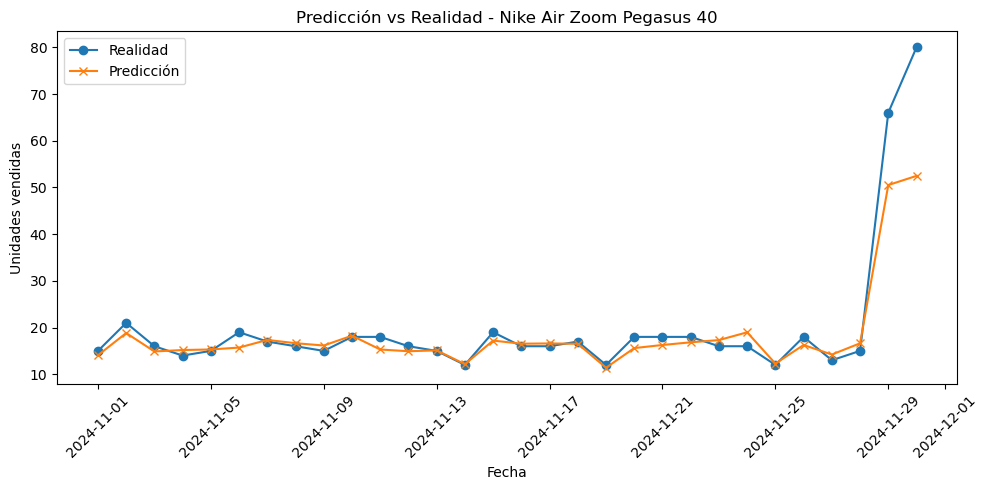

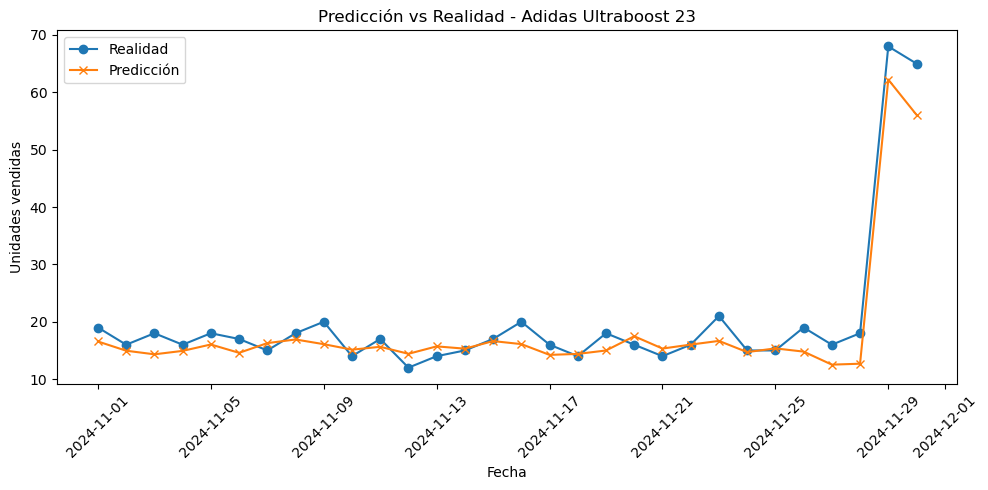

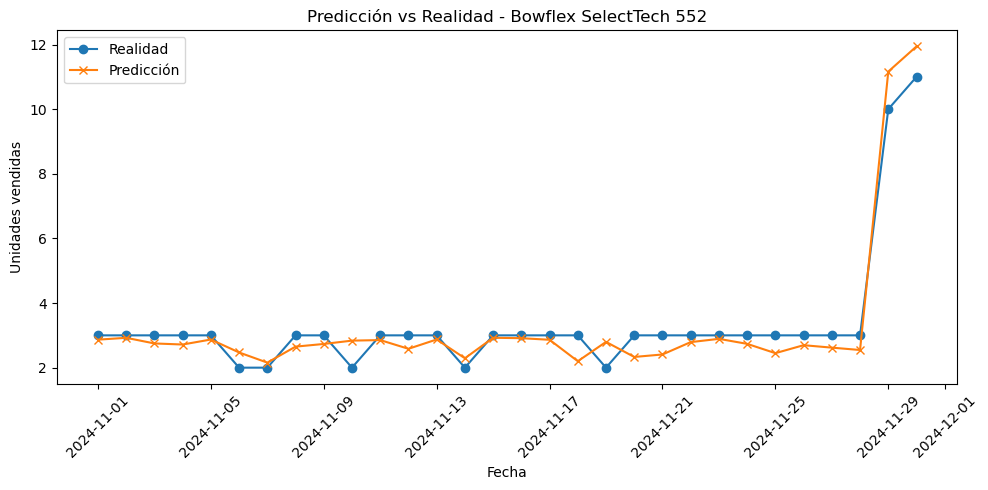

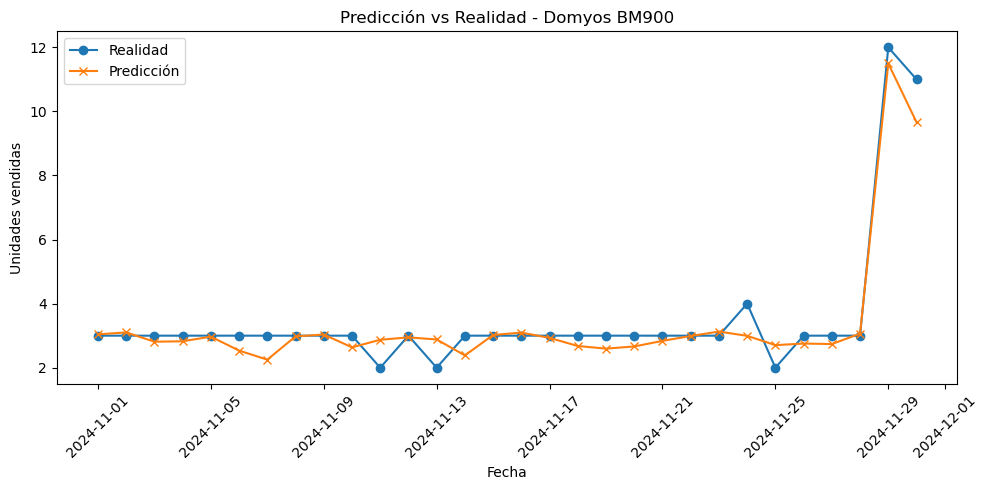

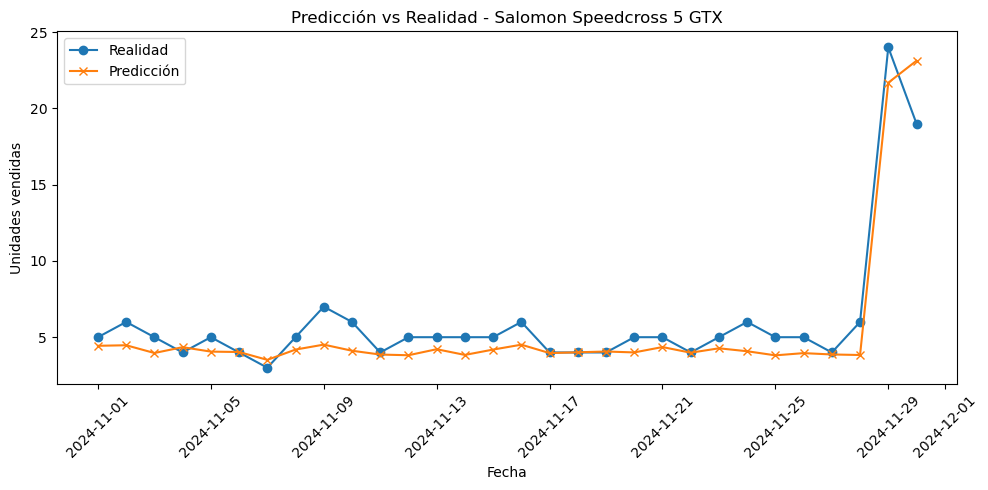

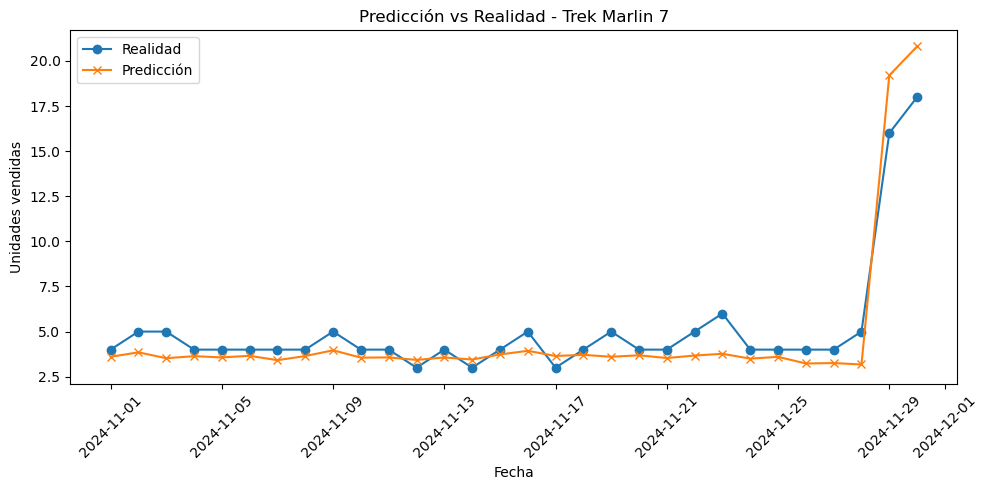

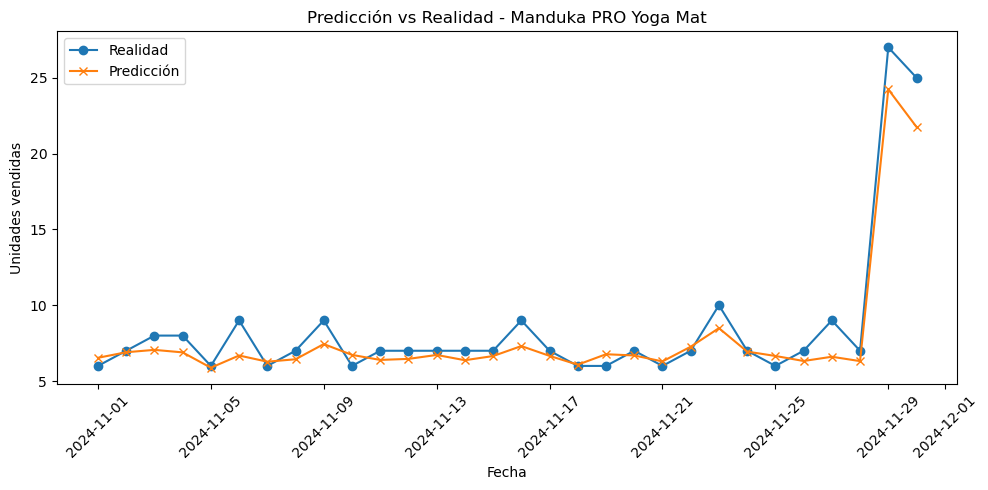

In [509]:
# Predicción para noviembre 2024 y productos estrella
productos_estrella = validation_df[(validation_df['año'] == 2024) & (validation_df['mes'] == 11) & (validation_df['es_estrella'] == 1)]['nombre'].unique()

for producto in productos_estrella:
    df_prod = validation_df[(validation_df['año'] == 2024) & (validation_df['mes'] == 11) & (validation_df['nombre'] == producto)]
    X_prod = df_prod[X_train.columns]
    y_real = df_prod['unidades_vendidas']
    y_pred = model.predict(X_prod)
    plt.figure(figsize=(10,5))
    plt.plot(df_prod['fecha'], y_real, marker='o', label='Realidad')
    plt.plot(df_prod['fecha'], y_pred, marker='x', label='Predicción')
    plt.title(f'Predicción vs Realidad - {producto}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [510]:
# Calcular MAE para cada producto estrella en noviembre 2024
from sklearn.metrics import mean_absolute_error
mae_dict = {}
for producto in productos_estrella:
    df_prod = validation_df[(validation_df['año'] == 2024) & (validation_df['mes'] == 11) & (validation_df['nombre'] == producto)]
    X_prod = df_prod[X_train.columns]
    y_real = df_prod['unidades_vendidas']
    y_pred = model.predict(X_prod)
    mae = mean_absolute_error(y_real, y_pred)
    mae_dict[producto] = mae

for producto, mae in mae_dict.items():
    print(f"MAE para {producto}: {mae:.2f}")

MAE para Nike Air Zoom Pegasus 40: 2.56
MAE para Adidas Ultraboost 23: 2.36
MAE para Bowflex SelectTech 552: 0.38
MAE para Domyos BM900: 0.34
MAE para Salomon Speedcross 5 GTX: 1.04
MAE para Trek Marlin 7: 0.89
MAE para Manduka PRO Yoga Mat: 0.88


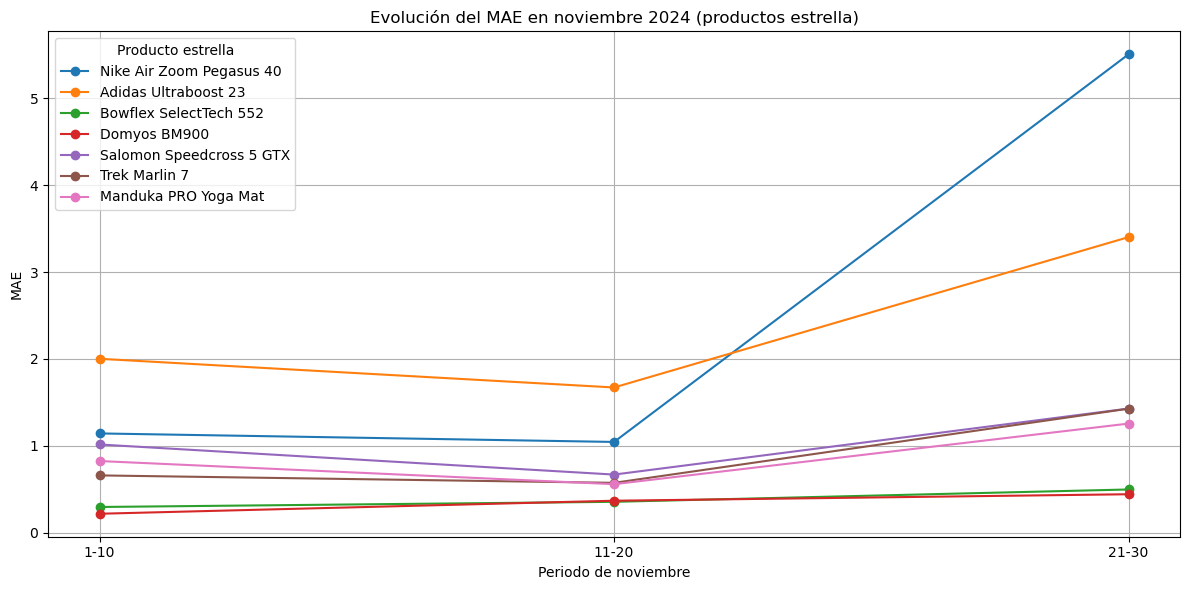

In [511]:
# Análisis de degradación del error (MAE) a lo largo de noviembre 2024 para los productos estrella
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# Definir los tres periodos de 10 días
periodos = [(1,10), (11,20), (21,30)]
mae_periodos = {producto: [] for producto in productos_estrella}

for producto in productos_estrella:
    df_prod = validation_df[(validation_df['año'] == 2024) & (validation_df['mes'] == 11) & (validation_df['nombre'] == producto)]
    for inicio, fin in periodos:
        df_periodo = df_prod[(df_prod['fecha'].dt.day >= inicio) & (df_prod['fecha'].dt.day <= fin)]
        if not df_periodo.empty:
            X_p = df_periodo[X_train.columns]
            y_real = df_periodo['unidades_vendidas']
            y_pred = model.predict(X_p)
            mae = mean_absolute_error(y_real, y_pred)
        else:
            mae = np.nan
        mae_periodos[producto].append(mae)

# Gráfica de evolución del MAE por producto estrella
dias = ['1-10', '11-20', '21-30']
plt.figure(figsize=(12,6))
for producto in productos_estrella:
    plt.plot(dias, mae_periodos[producto], marker='o', label=producto)
plt.title('Evolución del MAE en noviembre 2024 (productos estrella)')
plt.xlabel('Periodo de noviembre')
plt.ylabel('MAE')
plt.legend(title='Producto estrella')
plt.grid(True)
plt.tight_layout()
plt.show()

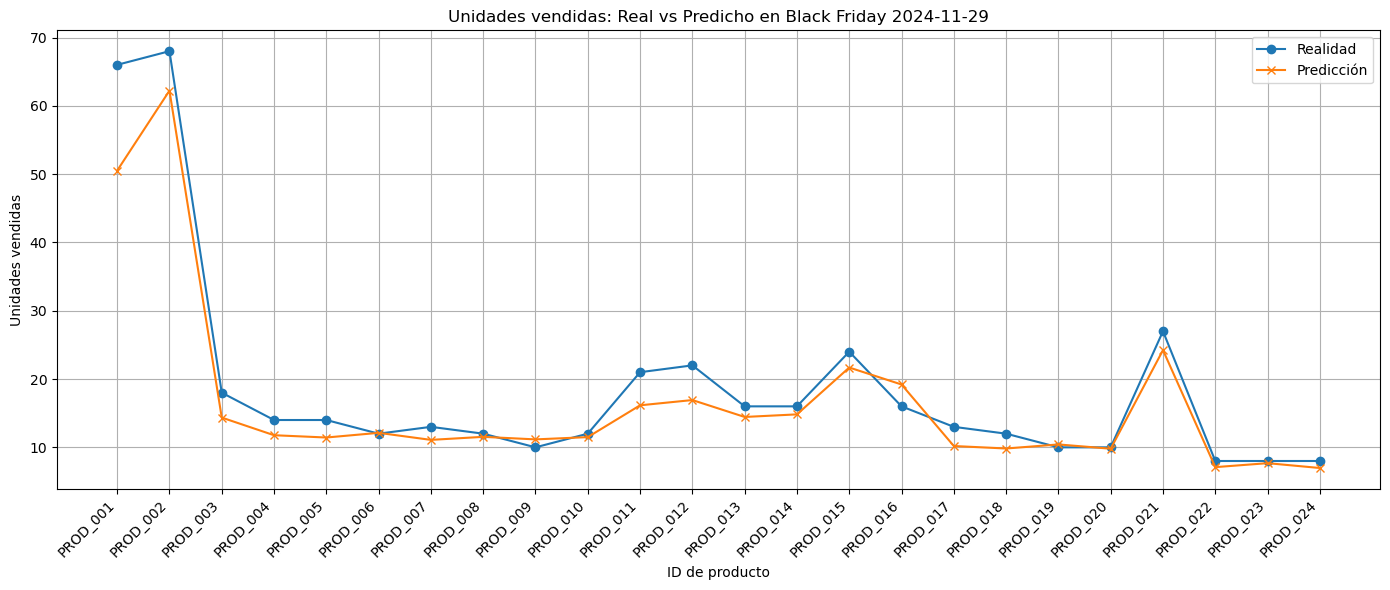

In [512]:
# Análisis específico para Black Friday 2024: real vs predicho para todos los productos
# Buscar la fecha de Black Friday 2024
df_bf = validation_df[(validation_df['año'] == 2024) & (validation_df['es_Black_Friday'] == True)]

# Si hay más de una fecha (por error), tomar la primera
if not df_bf.empty:
    fecha_bf = df_bf['fecha'].iloc[0]
    df_bf = validation_df[validation_df['fecha'] == fecha_bf]
    X_bf = df_bf[X_train.columns]
    y_real = df_bf['unidades_vendidas']
    y_pred = model.predict(X_bf)
    plt.figure(figsize=(14,6))
    plt.plot(df_bf['producto_id'], y_real, marker='o', label='Realidad')
    plt.plot(df_bf['producto_id'], y_pred, marker='x', label='Predicción')
    plt.title(f'Unidades vendidas: Real vs Predicho en Black Friday {fecha_bf.date()}')
    plt.xlabel('ID de producto')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45, ha='right')  # Rotar los IDs en diagonal
    plt.tight_layout()
    plt.show()
else:
    print('No se encontró registro de Black Friday 2024 en los datos de validación.')

In [513]:
# Reentrenar el modelo final con todos los datos históricos (2021-2024)
final_del_cols = ['fecha', 'ingresos']
final_del_cols += [col for col in df.columns if df[col].dtype == 'object']

X_final = df.drop(columns=final_del_cols + ['unidades_vendidas'])
y_final = df['unidades_vendidas']

final_model = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=500,
    max_depth=6,
    l2_regularization=1.0,
    random_state=42
)
final_model.fit(X_final, y_final)

print('Modelo final entrenado con todos los datos históricos (2021-2024)')

Modelo final entrenado con todos los datos históricos (2021-2024)


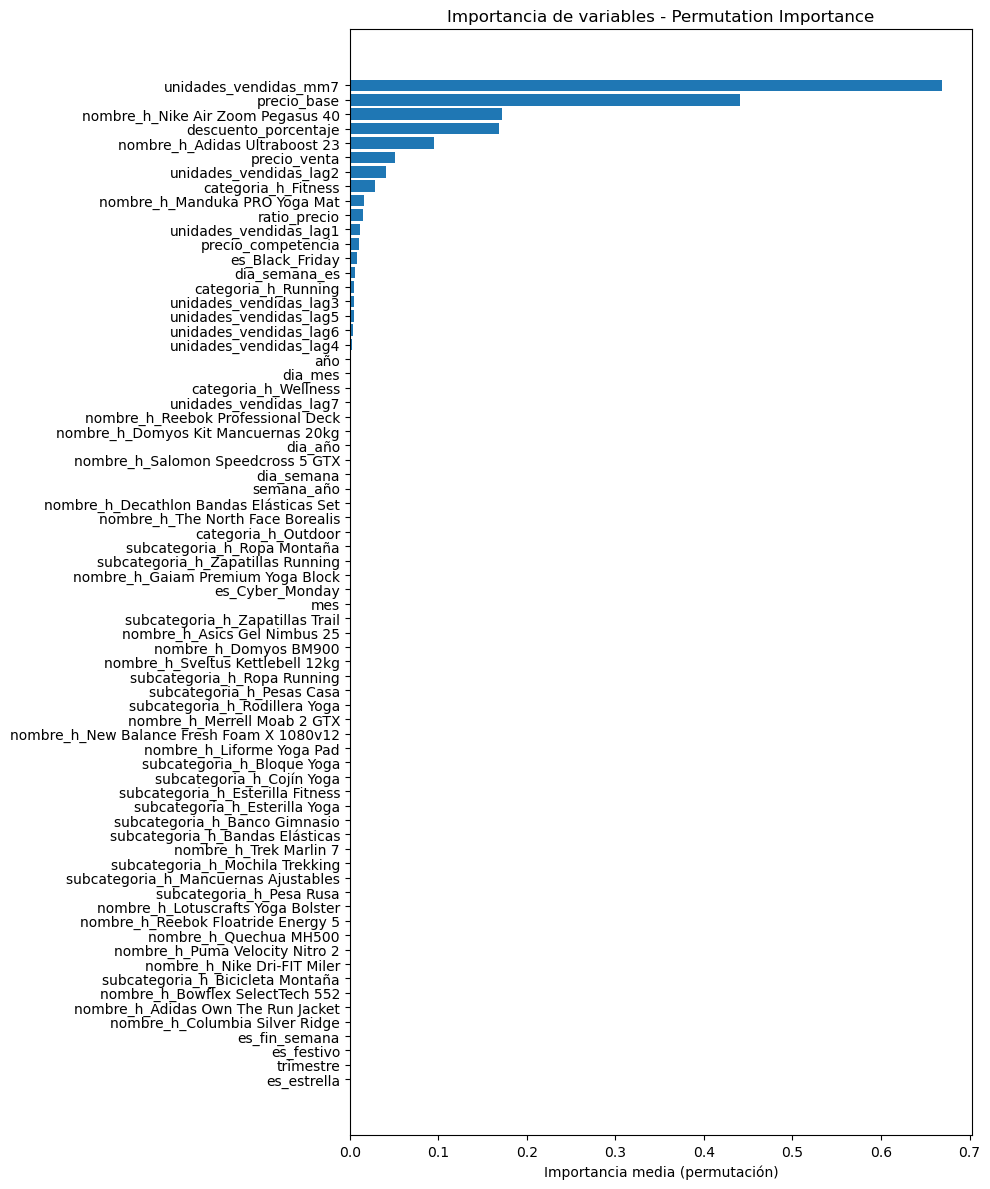

Modelo final guardado en ../models/modelo_final.joblib


In [514]:
# Importancia de variables con permutation importance y guardado del modelo final
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import joblib

# Calcular permutation importance
result = permutation_importance(final_model, X_final, y_final, n_repeats=10, random_state=42, n_jobs=-1)
importances = result.importances_mean
indices = np.argsort(importances)[::-1]

# Gráfico de barras horizontales ordenado
plt.figure(figsize=(10, 12))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X_final.columns[i] for i in indices])
plt.xlabel('Importancia media (permutación)')
plt.title('Importancia de variables - Permutation Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Guardar el modelo final
joblib.dump(final_model, '../models/modelo_final.joblib')
print('Modelo final guardado en ../models/modelo_final.joblib')